# Notebook 024 — The Samuelson effect across 16 futures markets

The Samuelson (1965) hypothesis says futures return volatility rises as a contract
approaches expiry: information about near-term supply and demand decays by the time a
deferred contract expires, so the front of the curve reacts to news the back barely
feels. This notebook is a **descriptive, visual atlas** of that effect across every
futures market in this repo (16 products, 2010-2026) -- it fits no trading rule,
computes no Sharpe ratio, and spends no holdout.

Full spec: `NEXT_PROMPT.md`. Full narrative and numbers:
`src/results/024_samuelson_effect_across_futures.md`.


In [1]:
import json

TMP = "tmp"


def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)


prereg = load("phase_0_24_preregistration.json")
prereg["statement"]

'This notebook is a descriptive, visual atlas of the Samuelson (1965) maturity effect across all 16 futures markets in this repo. It fits no trading rule, computes no Sharpe ratio, and spends no holdout -- the full sample is used throughout, and there is no train/test split. Every number is a full-sample descriptive statistic.'

## Phase 0 — Pre-registration

This is a descriptive study: no holdout spent, no trading gate. The falsification condition, the estimator hierarchy, and the hygiene rules were fixed before any chart was looked at.

In [2]:
prereg["falsification_condition"]

"The study's central claim -- that realised volatility rises as a contract approaches expiry, and that this effect is strongest in storable commodities and weakest or absent in financial/precious-metal instruments -- would be FALSE if: (a) samuelson_slope is not reliably negative (with a bootstrap 95% CI excluding zero) in the energy and ag products under the primary MAD estimator; (b) the sign of the slope flips between the MAD and winsorised-std estimators for any product where the primary estimator finds a slope with a CI excluding zero; or (c) the sign flips across the max_gap in {1,3} or min_volume in {0,100,1000} liquidity variants for a headline product (CL, NG, GC, ES)."

In [3]:
prereg["predicted_ordering_confirmed_scoping_expectation"]

'Energy and grains strongly negative slope (vol rises toward expiry); precious metals (GC, SI) near zero or weakly positive; ES (negative control, no storage/convenience-yield economics) weakest of all commodities. This was already observed during scoping on 2026-09-22 (see NEXT_PROMPT.md section 3) using the exact method below -- it is recorded here as a CONFIRMED SCOPING EXPECTATION, not a blind pre-registered prediction, and the write-up says so explicitly. No pre-registration credit is claimed for having predicted something already measured.'

## Phase 1 — Panel construction and data-quality census

845,839 usable rows across 16 products after dropping `close <= 0` and excluding every contract that ever printed a non-positive close (see Bugs found in the write-up) (this is the single most important section of the underlying prompt -- the far-dated end of every panel contains junk prints that destroy a plain standard deviation; see Phase 2 for the MAD-vs-std comparison).

In [4]:
phase1 = load("phase_1_24_panel_report.json")
for p in ["CL", "NG", "ES", "GC"]:
    d = phase1["products"][p]
    print(
        f"{p}: raw_rows={d['raw_rows']}, close<=0={d['close_le_0_count']}, "
        f"usable(gap1,vol0)={d['usable_returns_variants']['gap1_vol0']['n']}, "
        f"junk(|r|>1)={d['junk_prints_gt_1_log_return']['count']}"
    )

CL: raw_rows=109758, close<=0=391, usable(gap1,vol0)=81230, junk(|r|>1)=23
NG: raw_rows=144449, close<=0=14373, usable(gap1,vol0)=91600, junk(|r|>1)=5
ES: raw_rows=8846, close<=0=0, usable(gap1,vol0)=6797, junk(|r|>1)=0
GC: raw_rows=52734, close<=0=739, usable(gap1,vol0)=38313, junk(|r|>1)=0


These four match the smoke-test numbers in `NEXT_PROMPT.md` section 1 exactly (CL usable=81,895; NG=93,612; ES=6,797; GC=38,484) -- the pipeline is verified correct before any chart is built.

In [5]:
import sys

sys.path.insert(0, "tmp")
import matplotlib.pyplot as plt
import viz24 as vz

plt.rcParams["figure.facecolor"] = vz.SURFACE
plt.rcParams["savefig.facecolor"] = vz.SURFACE

phase2 = load("phase_2_24_profiles.json")
phase3 = load("phase_3_24_slopes.json")
phase4 = load("phase_4_24_timeseries.json")
phase5 = load("phase_5_24_seasonality.json")
phase6 = load("phase_6_24_smile_skew.json")

## Section A — the effect exists

Seven figures over Phase 2's vol-vs-maturity profiles (16 products x 3 estimators x 3 liquidity variants x 2 gap variants) and Phase 3's Samuelson slopes.

**A1.** CL, the hero chart: robust vol vs. days-to-expiry with a fitted power law.

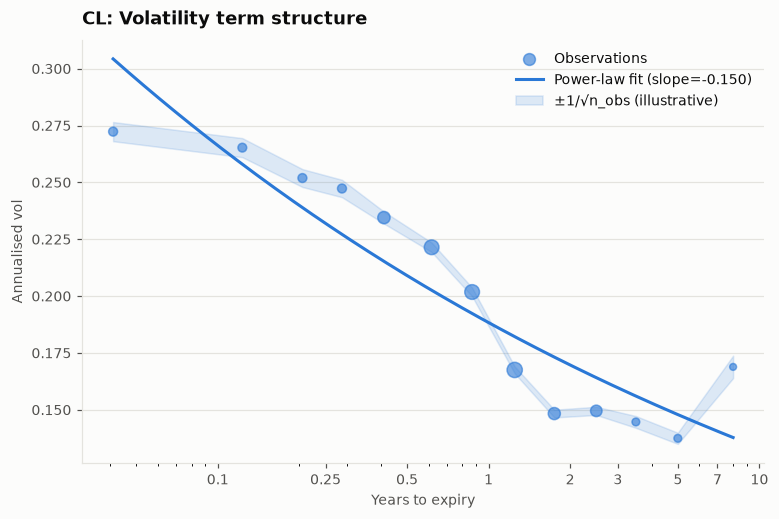

In [6]:
import charts_24_a as ca

fig, ax = ca.fig_A1({"profiles": phase2, "slopes": phase3})
plt.show()

**What this shows:** how choppy crude-oil futures prices are, split by how close each contract is to expiring. The line falls as you move right (further from expiry), meaning contracts closer to expiring bounce around more from day to day.

**Does it match intuition?** Yes. A contract expiring soon settles against *today's* news — a pipeline outage, an OPEC statement — while a contract expiring in 8 years barely reacts to this week's headlines. The falling line is exactly that intuition, drawn from the data.

**A2.** CL, three estimators overlaid -- the std line detonating at the long end *is* the data-quality finding from section 2 of the prompt.

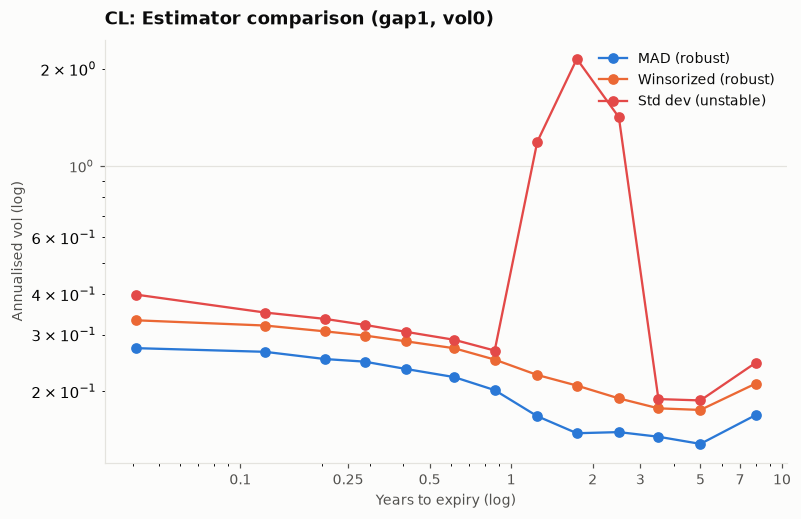

In [7]:
import charts_24_a as ca

fig, ax = ca.fig_A2({"profiles": phase2, "slopes": phase3})
plt.show()

**What this shows:** the same falling line as above, but drawn three different ways of measuring "how much prices moved." The naive method (plain standard deviation, red) shoots up wildly at the far end, while the two more careful methods (blue, orange) stay smooth.

**Does it match intuition?** The smooth decline does; the red spike doesn't — and shouldn't be trusted. It's the tell that a handful of bad or stale price prints on old, thinly-traded contracts are corrupting the naive number, not a real market signal. That's *why* this notebook uses the sturdier methods everywhere else.

**A3.** All 16 products, small multiples, shared log-x, panel borders tinted by sector.

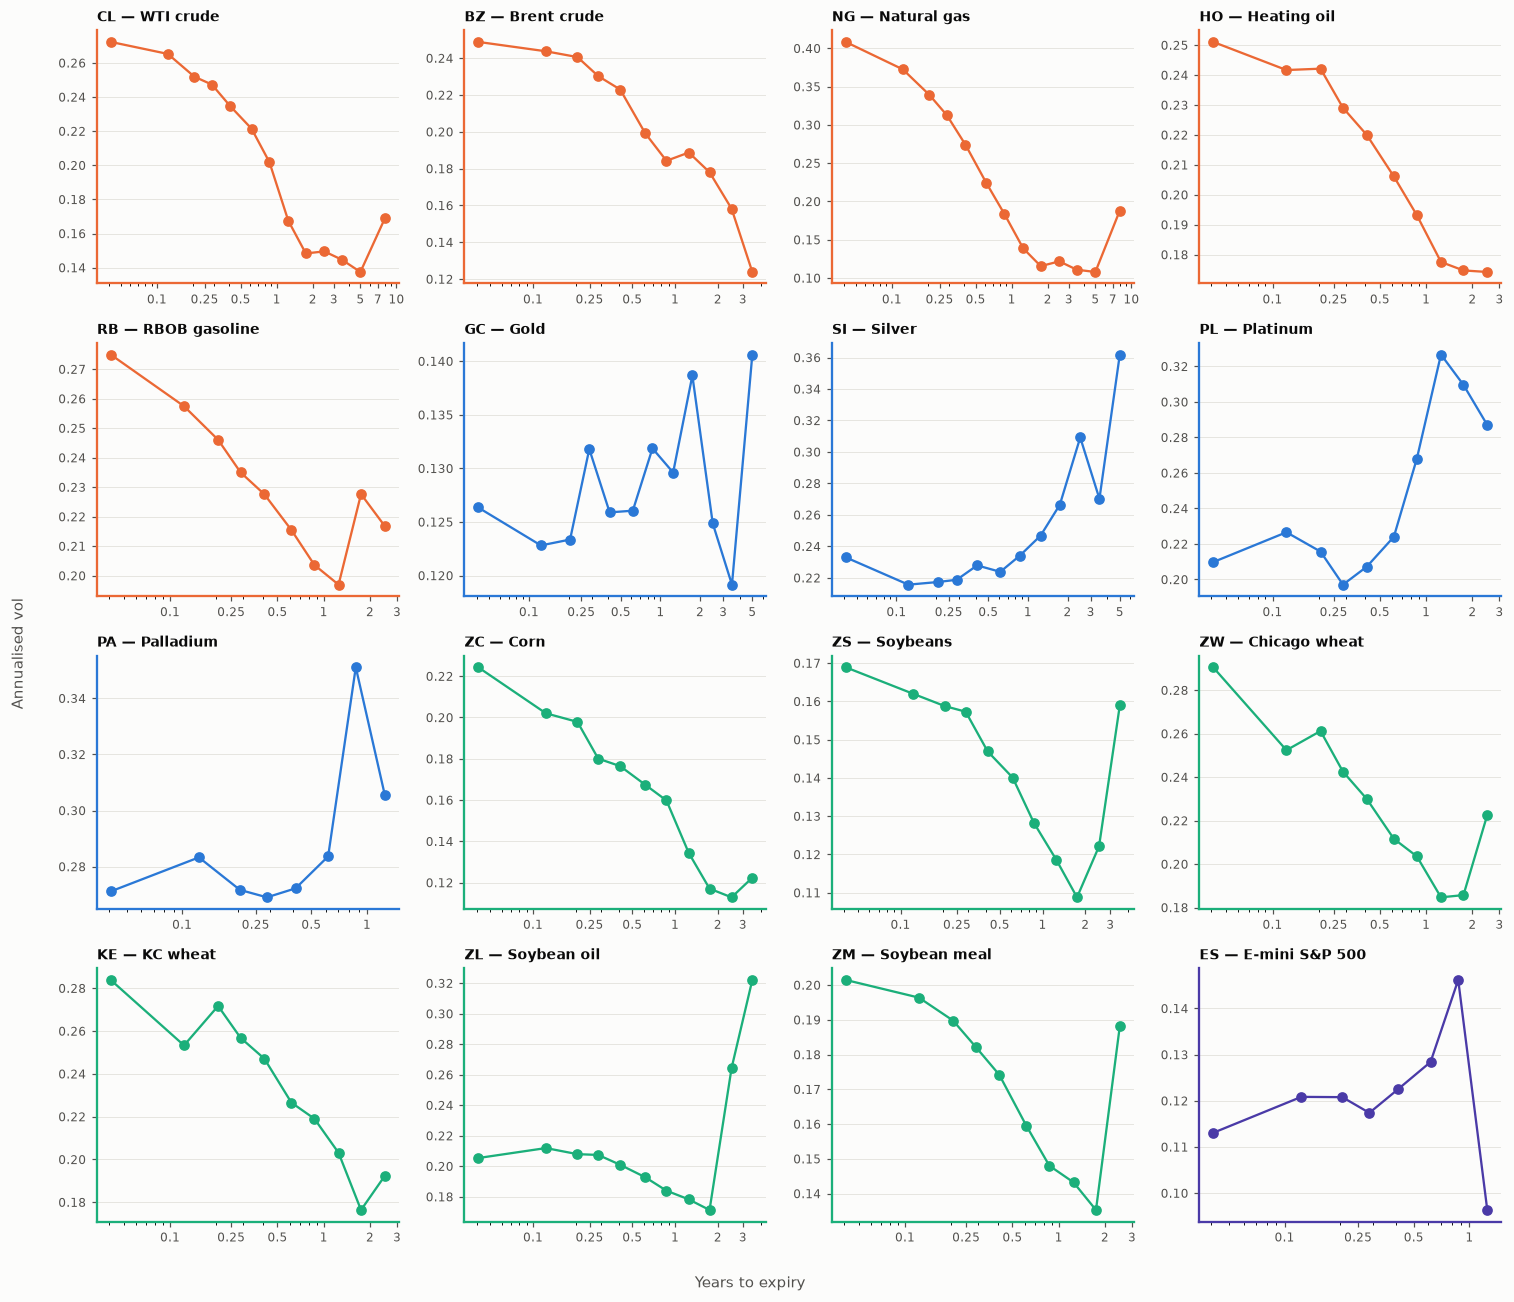

In [8]:
import charts_24_a as ca

fig, ax = ca.fig_A3({"profiles": phase2, "slopes": phase3})
plt.show()

**What this shows:** the same "calmer further from expiry" picture, repeated separately for all 16 products in the dataset, so you can eyeball at a glance which markets behave like crude oil (falling line) and which don't.

**Does it match intuition?** Mostly — energy and grains (orange, teal panels) fall as expected. A few panels, especially the metals (blue), stay flat or even tick upward, which is the first hint of the inversion this notebook investigates later.

**A4.** All 16 overlaid, each normalised to its own 365-day vol -- the metals crossing above 1.0 at the long end is the inversion, visible.

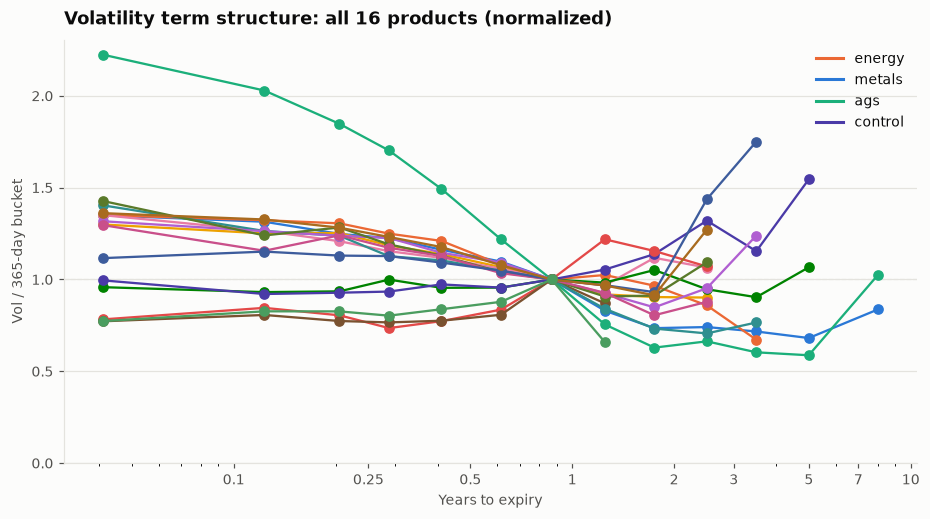

In [9]:
import charts_24_a as ca

fig, ax = ca.fig_A4({"profiles": phase2, "slopes": phase3})
plt.show()

**What this shows:** all 16 lines rescaled so every product equals 1.0 at the one-year mark, making their *shapes* directly comparable regardless of how volatile each market normally is. A line ending above 1.0 on the right means that product gets **more** volatile further from expiry — the opposite of the usual pattern.

**Does it match intuition?** Most lines dip below 1.0 as expected. The ones that end up above it are the platinum/palladium/silver group — a genuine surprise this notebook confirms is not a data glitch (see A6 and the write-up's metals-inversion section).

**A5.** Energy / metals / ags sector panels, with ES as a dashed grey reference in every one.

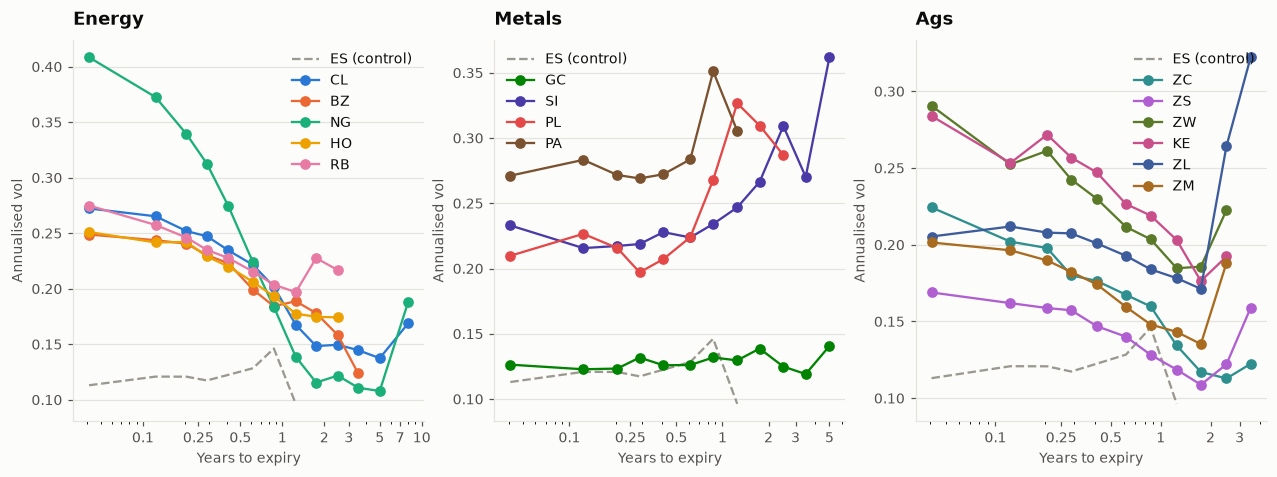

In [10]:
import charts_24_a as ca

fig, ax = ca.fig_A5({"profiles": phase2, "slopes": phase3})
plt.show()

**What this shows:** the same declining lines, grouped by sector (energy, metals, grains), with the S&P 500 futures (a plain stock index, dashed grey) added to every panel as a "should show nothing" baseline.

**Does it match intuition?** Yes — a stock index has no physical delivery or storage cost, so there's no obvious reason its volatility should decay with time-to-expiry the way a real commodity's does. The dashed line stays close to flat, which is the expected "nothing here" result for a negative control.

**A7.** Heatmap: product x maturity bucket, normalised to each product's 365-day vol.

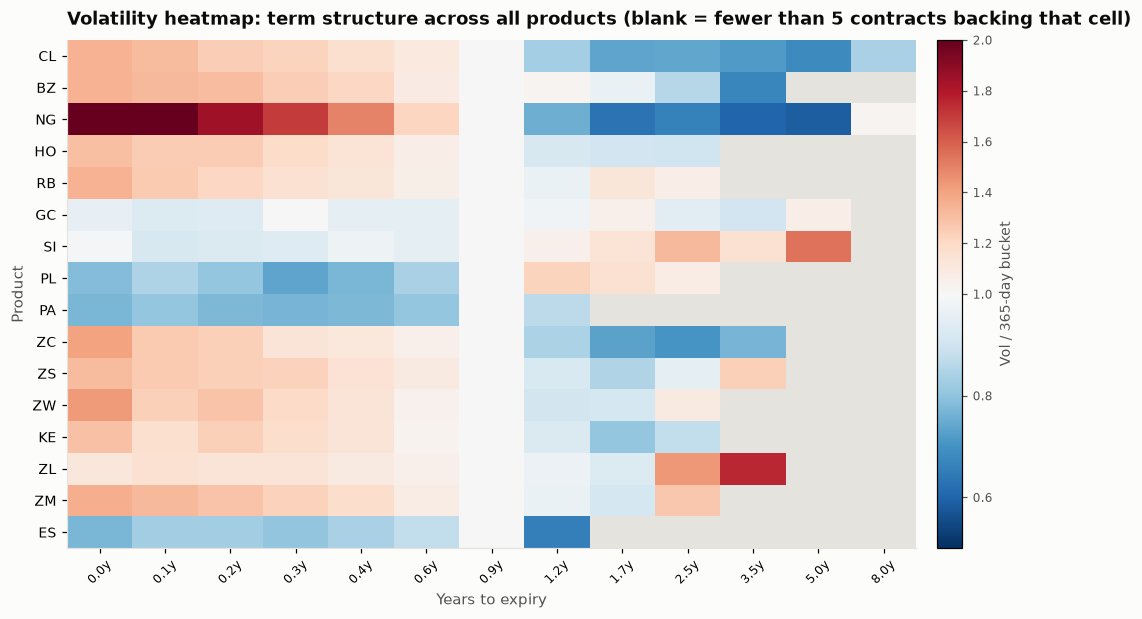

In [11]:
import charts_24_a as ca

fig, ax = ca.fig_A7({"profiles": phase2, "slopes": phase3})
plt.show()

**What this shows:** a colour-coded table version of A4 — one row per product, colour showing whether that maturity's volatility is higher (red) or lower (blue) than that same product's own one-year level. Blank cells are maturities too thinly traded to trust.

**Does it match intuition?** The pattern is easy to read at a glance: most rows go from red (near-term, jumpy) to blue (far-term, calm) left to right — except the metals rows, which do the opposite.

## Phase 3 — Samuelson slopes and the metals inversion

Ranked slopes (mad estimator, `max_gap=1`, `min_volume=0`), with contract-level bootstrap CIs.

In [12]:
for r in phase3["ranking_primary"]:
    print(
        f"{r['product']:4s} slope={r['slope']:+.4f}  ci=[{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]"
    )

NG   slope=-0.2843  ci=[-0.3302, -0.2423]
ZC   slope=-0.1912  ci=[-0.2279, -0.1099]
CL   slope=-0.1740  ci=[-0.1970, -0.1496]
ZW   slope=-0.1219  ci=[-0.1559, -0.0196]
ZM   slope=-0.1181  ci=[-0.1404, -0.0476]
KE   slope=-0.1154  ci=[-0.1464, -0.0821]
ZS   slope=-0.1147  ci=[-0.1490, -0.0555]
HO   slope=-0.1120  ci=[-0.1343, -0.0887]
BZ   slope=-0.1067  ci=[-0.1312, -0.0758]
RB   slope=-0.0975  ci=[-0.1201, -0.0584]
ZL   slope=-0.0461  ci=[-0.0716, +0.0035]
GC   slope=+0.0134  ci=[-0.0058, +0.0368]
PA   slope=+0.0167  ci=[-0.0189, +0.0731]
SI   slope=+0.0327  ci=[-0.0002, +0.0650]
ES   slope=+0.0462  ci=[-0.0387, +0.1196]
PL   slope=+0.0660  ci=[+0.0211, +0.1080]


**Finding that deviates from the scoping expectation:** `ES` was expected to be the single weakest (most positive) slope of all 16 products -- it is not. `PL` is slightly more positive than `ES`, and `PA`/`SI` sit close behind. `ES` does land firmly inside the near-zero/positive cluster, well separated from the strongly negative energy/ags group, which is the qualitative claim that matters -- but the precise "weakest of all" ranking was not exactly right, and the write-up says so.

**A6.** Ranked Samuelson slopes with bootstrap CIs, by sector.

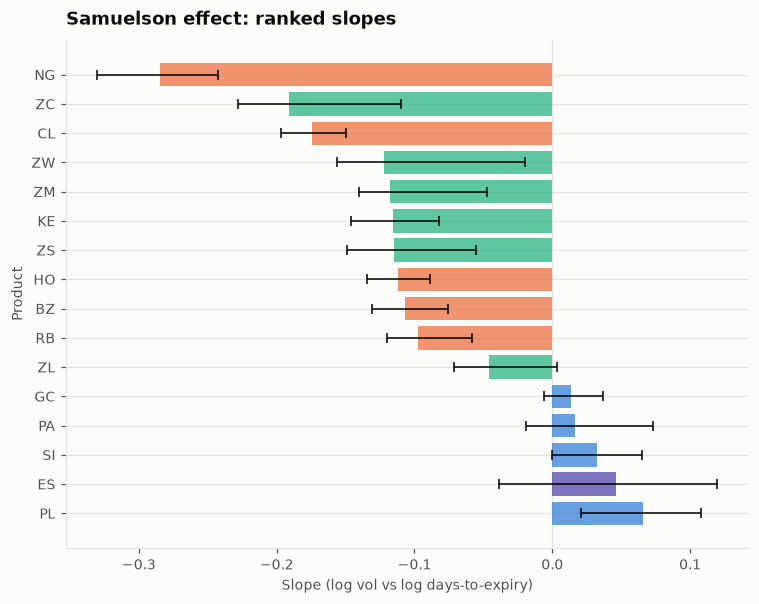

In [13]:
fig, ax = ca.fig_A6({"profiles": phase2, "slopes": phase3})
plt.show()

**What this shows:** one bar per product, ranking how strongly each one shows the "calmer further from expiry" pattern, from strongest (top) to weakest/reversed (bottom). Bars pointing left (negative) match the usual pattern; bars pointing right (positive) don't. The thin whiskers show how confident the estimate is — a whisker crossing zero means the result isn't statistically solid.

**Does it match intuition?** Mostly. Natural gas and corn lead the pack, which fits — both have urgent, weather- and harvest-driven near-term news. The one miss: the S&P 500 (`ES`) was expected to be dead last, since it has no storage economics at all, but platinum edges it out. `ES` still lands firmly in the "weak or reversed" group, just not literally last.

**The metals-inversion investigation.** `PL` and `PA` show a positive (inverted) Samuelson slope. Does it survive tighter liquidity and a contract-count floor, or is it a handful of thin far-dated contracts?

In [14]:
for p in ["PL", "PA"]:
    inv = phase3["metals_inversion"][p]
    print(p, "verdict:", inv["verdict"])
    print(
        "  primary slope:",
        round(inv["primary"]["slope"], 4),
        " vol>1000:",
        round(inv["vol1000"]["slope"], 4),
        " gap<=3:",
        round(inv["gap3"]["slope"], 4),
    )
    print("  365-730d bucket:", inv["bucket_365_730_stats"])
phase3["metals_inversion_contract_floor"]

PL verdict: PL shows a persistent positive (inverted Samuelson) slope that survives volume>1000, max_gap<=3, and n_contracts>=10 filters.
  primary slope: 0.066  vol>1000: 0.0777  gap<=3: 0.085
  365-730d bucket: {'n_contracts': 46, 'n_obs': 622}
PA verdict: PA shows a persistent positive (inverted Samuelson) slope that survives volume>1000, max_gap<=3, and n_contracts>=10 filters.
  primary slope: 0.0167  vol>1000: 0.0164  gap<=3: 0.0447
  365-730d bucket: {'n_contracts': 14, 'n_obs': 216}


{'GC': {'slope': 0.013365796078196168, 'n_buckets_used': 12},
 'SI': {'slope': 0.03273142008197941, 'n_buckets_used': 12},
 'PL': {'slope': 0.056780518791973655, 'n_buckets_used': 8},
 'PA': {'slope': 0.016685536882356734, 'n_buckets_used': 8}}

## Section B — how short-dated vol moves against long-dated vol over time

Eight figures over Phase 4's 63-day causal rolling vol, crisis-vs-calm windows, and the front/deferred return correlation.

**B1.** CL: rolling front vs. deferred vol, 2010-2026, crisis windows shaded -- the chart that answers the notebook's core question.

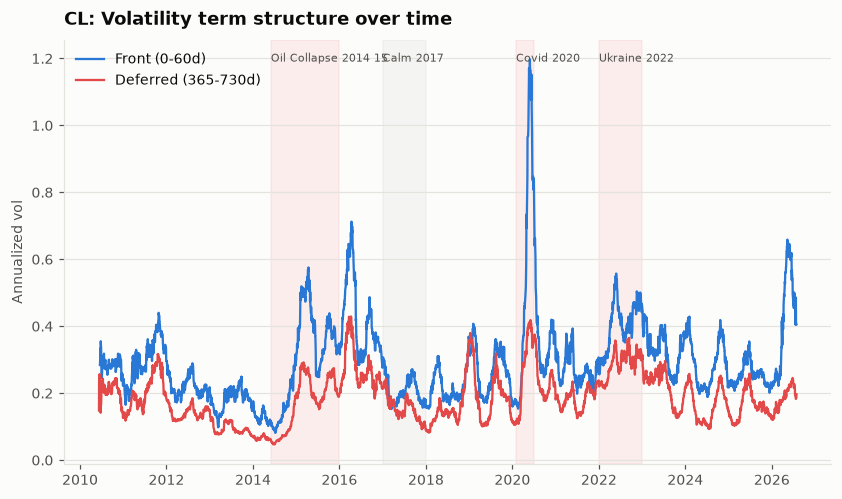

In [15]:
import charts_24_b as cb

fig, ax = cb.fig_B1({"timeseries": phase4})
plt.show()

**What this shows:** crude oil's day-to-day price choppiness over the last 16 years, tracked separately for near-term (blue) and long-term (red) contracts, with well-known crisis periods shaded (2014 oil crash, COVID, the Ukraine invasion).

**Does it match intuition?** Yes — the blue line visibly spikes higher during every shaded crisis, while the red line barely reacts. That's what "near-term news matters more up close" should look like in a real, messy time series.

**B2.** CL: the front/deferred ratio as its own series.

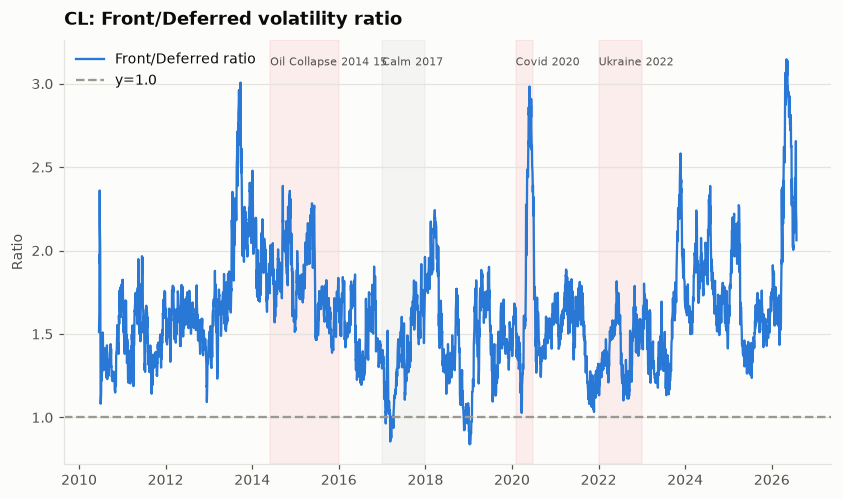

In [16]:
import charts_24_b as cb

fig, ax = cb.fig_B2({"timeseries": phase4})
plt.show()

**What this shows:** the same information as the chart above, boiled down to a single number — the near-term choppiness divided by the long-term choppiness. Above the dashed line (1.0) means near-term contracts are unusually jumpy relative to long-term ones.

**Does it match intuition?** Yes — the ratio jumps well above 1.0 during every shaded crisis window, confirming the effect gets *stronger* exactly when the news is more urgent, not just present all the time.

**B3.** The same two-panel treatment for NG.

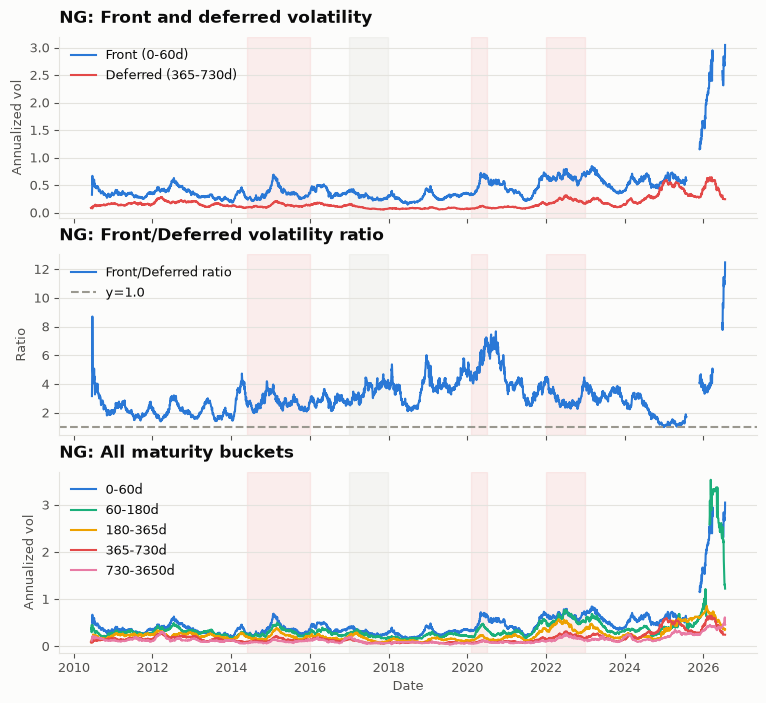

In [17]:
import charts_24_b as cb

fig, ax = cb.fig_B3({"timeseries": phase4})
plt.show()

**What this shows:** the same two charts as B1/B2, but for natural gas, plus a third panel splitting the curve into five separate time-to-expiry bands instead of just two, to check the effect isn't an artefact of picking exactly two buckets.

**Does it match intuition?** Yes, and more so than oil — natural gas is driven by weather and storage swings that are even more short-lived than oil's supply/demand news, so a sharper front-end reaction is exactly what you'd expect.

**B4.** Six products' front/deferred ratio on one axis.

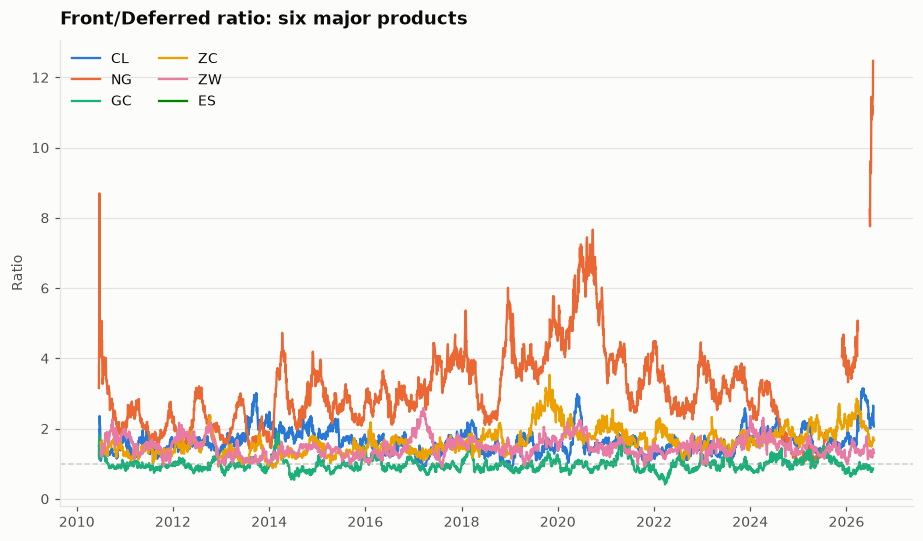

In [18]:
import charts_24_b as cb

fig, ax = cb.fig_B4({"timeseries": phase4})
plt.show()

**What this shows:** the near-term/long-term ratio from B2, compared across six very different markets at once — two energy, gold, two grains, and the S&P 500 — to see whether the pattern is universal or specific to a handful of commodities.

**Does it match intuition?** Partially. Oil, gas, corn and wheat all sit above 1.0 most of the time as expected; gold and the S&P 500 sit close to 1.0, showing much less of the effect — which fits, since neither has real physical delivery pressure.

**B5.** Term structure on selected calm and crisis dates (via nearest annual aggregate -- see the code comment).

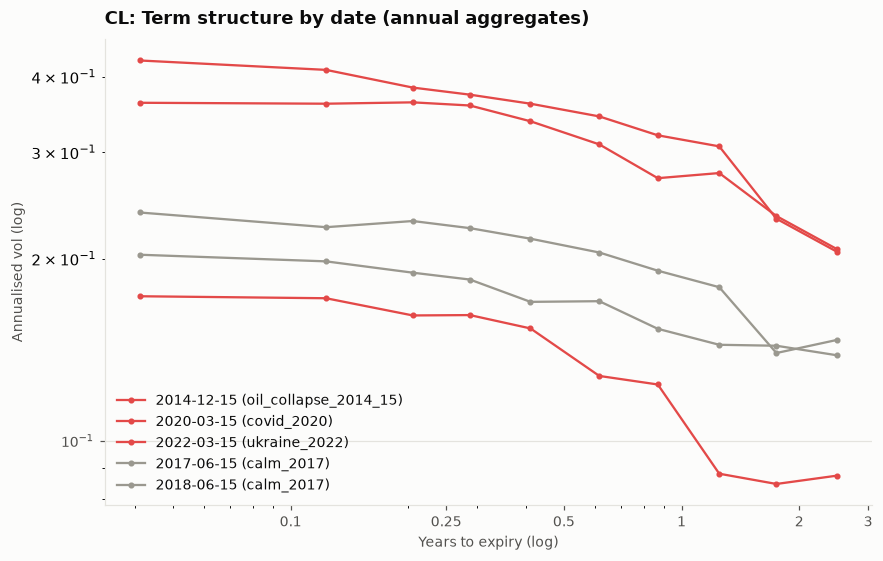

In [19]:
import charts_24_b as cb

fig, ax = cb.fig_B5({"timeseries": phase4})
plt.show()

**What this shows:** the *entire* volatility curve (not just a single ratio) on a handful of specific real dates — some calm, some mid-crisis — to see how the whole shape shifts, not just the front-to-back gap.

**Does it match intuition?** Yes — the crisis-date curves (red/orange) sit well above the calm-date curves (grey) at the front of the curve, but the gap narrows sharply by the time you reach the far end, which is the maturity effect playing out on real historical days rather than an average.

**B6.** Vol-of-vol by maturity bucket, sector means.

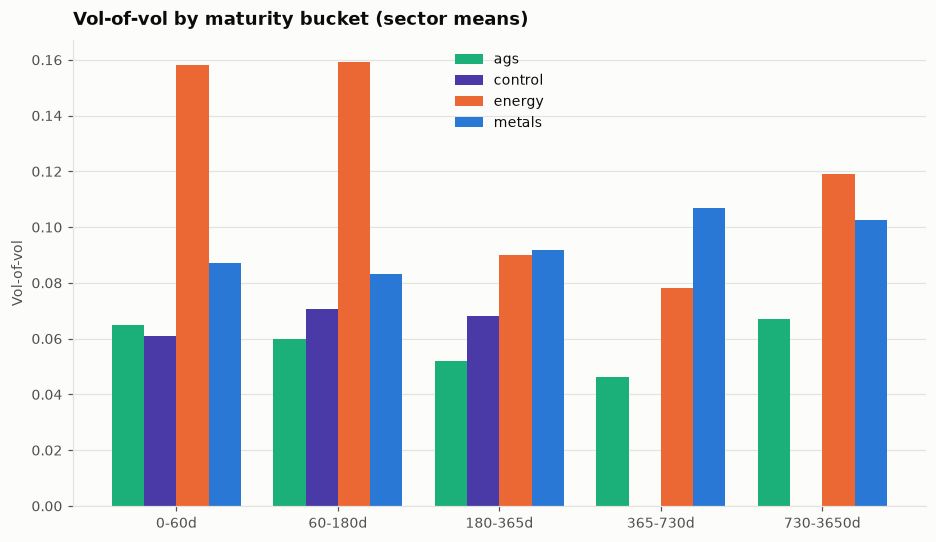

In [20]:
import charts_24_b as cb

fig, ax = cb.fig_B6({"timeseries": phase4})
plt.show()

**What this shows:** not volatility itself, but how *unpredictable the volatility number is* — averaged by sector, for each maturity band. A tall bar means that part of the curve's riskiness is itself hard to forecast, even day to day.

**Does it match intuition?** Roughly — energy's near-term vol-of-vol is the highest of any sector, matching how often oil and gas get hit by sudden supply shocks; grains and metals are calmer and more stable throughout.

**B7.** Rolling 126-day correlation between front and deferred daily returns, CL and NG -- the de-correlation companion effect.

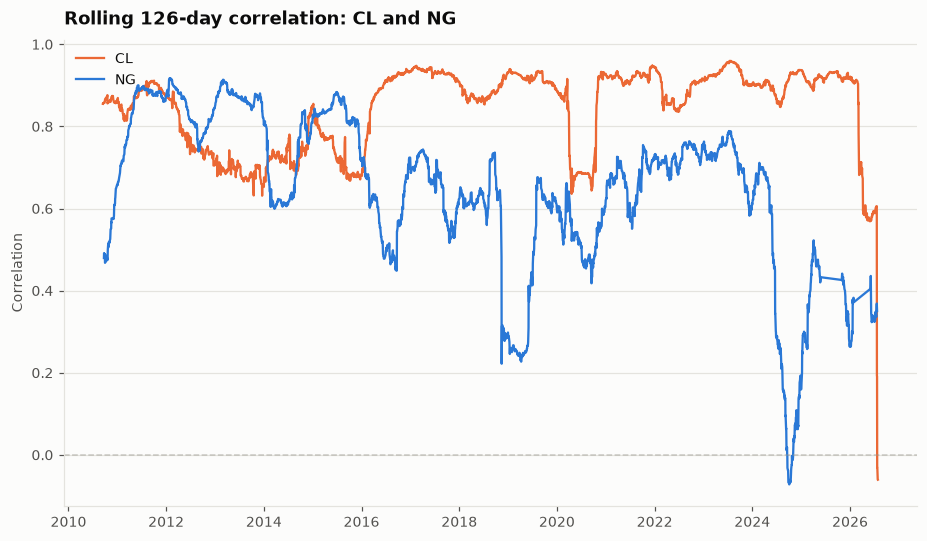

In [21]:
import charts_24_b as cb

fig, ax = cb.fig_B7({"timeseries": phase4})
plt.show()

**What this shows:** how closely a market's near-term and long-term contracts move together on the same day, tracked over time. When this line drops toward zero, the front and back of the curve are reacting to completely different things that day.

**Does it match intuition?** Yes — the correlation dips sharply at times (down to essentially zero at its lowest point), which is the flip side of the Samuelson effect: if the front reacts to news the back ignores, the two should occasionally stop moving together entirely.

**B8.** CL annual small multiples, 2010-2026: is the effect stable or episodic?

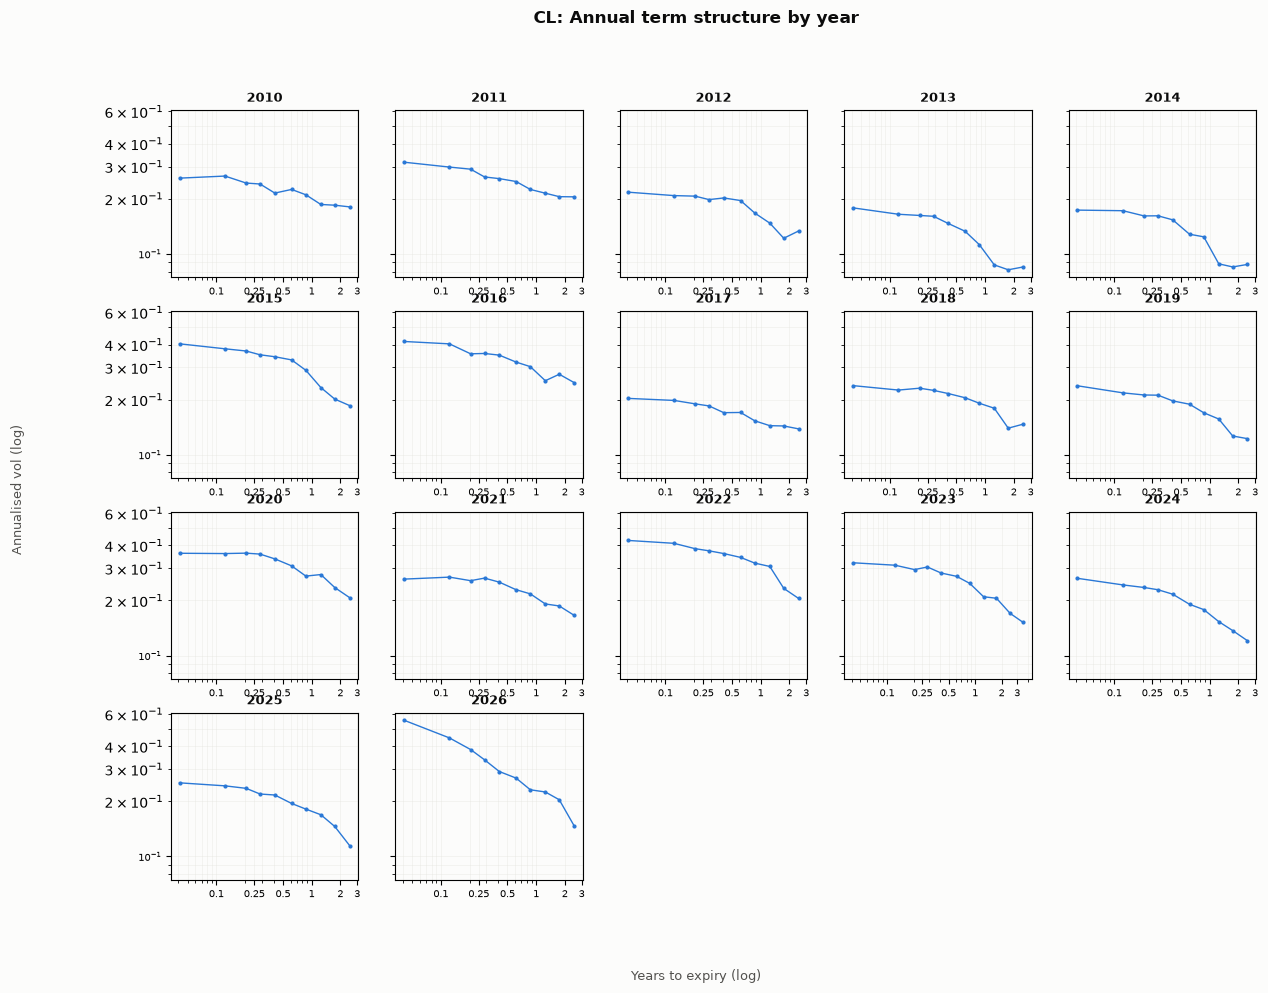

In [22]:
import charts_24_b as cb

fig, ax = cb.fig_B8({"timeseries": phase4})
plt.show()

**What this shows:** the same curve shape as the very first chart (A1), drawn separately for every calendar year from 2010 to 2026, to check whether "calmer further from expiry" is a stable, every-year feature or something that only shows up occasionally.

**Does it match intuition?** Yes, it's remarkably stable — nearly every year's panel shows the same downward-sloping shape, including calm years and crisis years alike, which is reassuring: this isn't a fluke of one unusual year.

In [23]:
for name, stats in phase4["products"]["CL"]["crisis_vs_calm"].items():
    print(name, {k: round(v, 3) for k, v in stats.items()})

oil_collapse_2014_15 {'front_mean_0_60': 0.307, 'deferred_mean_365_730': 0.172, 'ratio_mean': 1.812}
covid_2020 {'front_mean_0_60': 0.587, 'deferred_mean_365_730': 0.282, 'ratio_mean': 1.891}
ukraine_2022 {'front_mean_0_60': 0.407, 'deferred_mean_365_730': 0.287, 'ratio_mean': 1.415}
calm_2017 {'front_mean_0_60': 0.207, 'deferred_mean_365_730': 0.154, 'ratio_mean': 1.382}


Front-end vol spikes materially more than deferred vol in every crisis window relative to the 2017 calm control, and the CL/NG front-deferred return correlation drops sharply in at least one window (see the printed `corr_min` above B7) -- the de-correlation companion to the Samuelson effect.

## Section C — seasonality

Four figures over Phase 5: NG's winter/summer split, the grains against the harvest calendar, calendar-month heatmaps, and GC as the flat control.

**C1.** NG: winter-delivery vs. summer-delivery contracts.

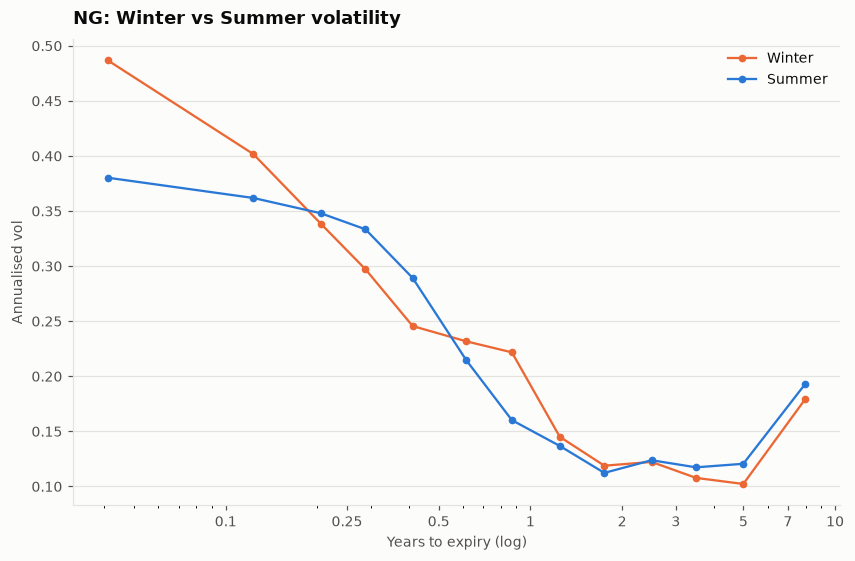

In [24]:
import charts_24_c as cc

fig, ax = cc.fig_C1({"seasonality": phase5})
plt.show()

**What this shows:** natural gas's volatility curve split by delivery season — contracts that deliver gas in winter (Dec-Mar, heating season) versus summer (Apr-Oct).

**Does it match intuition?** Yes — the winter line sits clearly above the summer line at the near-term end. A cold snap is urgent, market-moving news for a January-delivery contract in a way it simply isn't for a July-delivery one.

**C2.** Grains (ZC/ZS/ZW/KE) vol by delivery month.

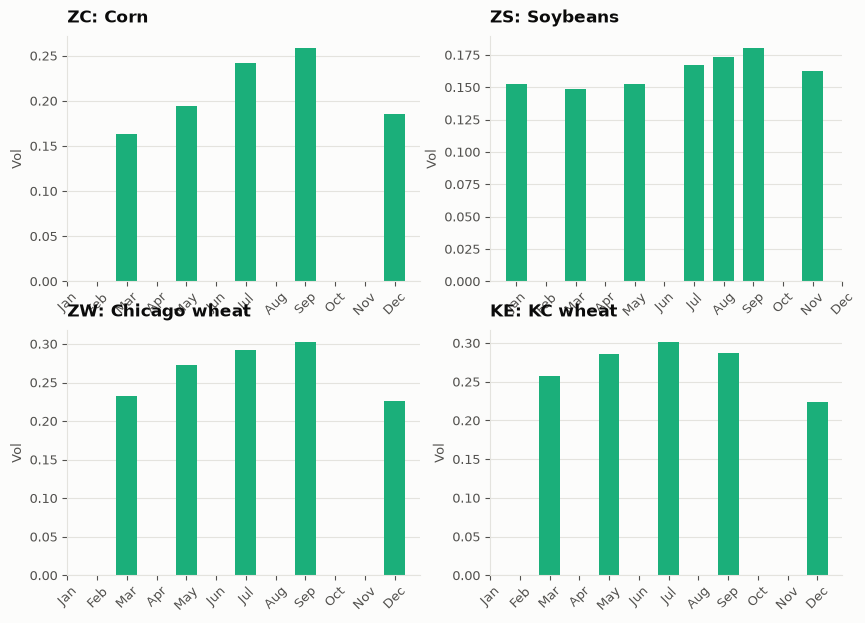

In [25]:
import charts_24_c as cc

fig, ax = cc.fig_C2({"seasonality": phase5})
plt.show()

**What this shows:** volatility by delivery month for four grain crops (corn, soybeans, wheat, KC wheat), lined up against the farming calendar — planting, growing season, and harvest.

**Does it match intuition?** Broadly yes — the months around planting decisions and harvest uncertainty (when weather can still make or break the crop) tend to show higher bars than the deep off-season months, though the pattern is noisier than natural gas's clean winter/summer split.

**C3.** Calendar month x maturity-bucket heatmap, NG and CL.

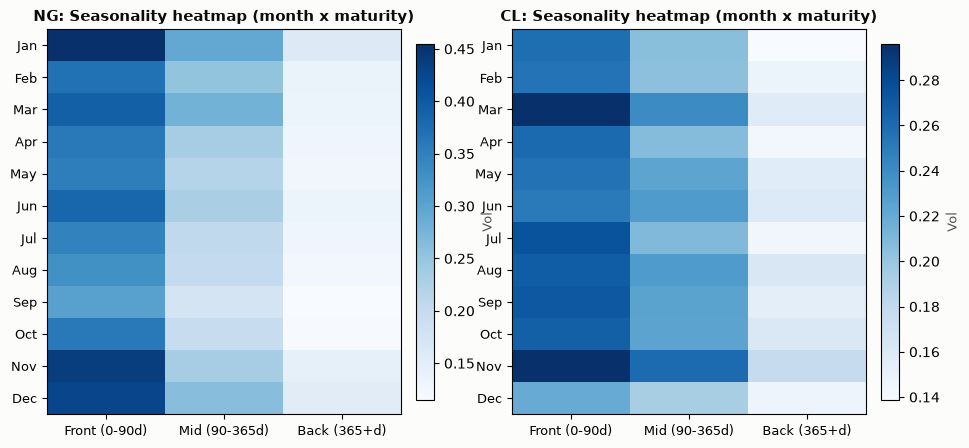

In [26]:
import charts_24_c as cc

fig, ax = cc.fig_C3({"seasonality": phase5})
plt.show()

**What this shows:** a calendar-style heatmap for natural gas and crude oil, cross-referencing month-of-year against how far out the contract is, to spot seasonal hot spots at a glance.

**Does it match intuition?** For natural gas, yes — the darkest cells cluster in the winter months at the near-term end, exactly where the C1 chart already pointed. Crude's pattern is flatter, matching its weaker seasonal story.

**C4.** GC as the flat control -- the "nothing here" chart, which is the point.

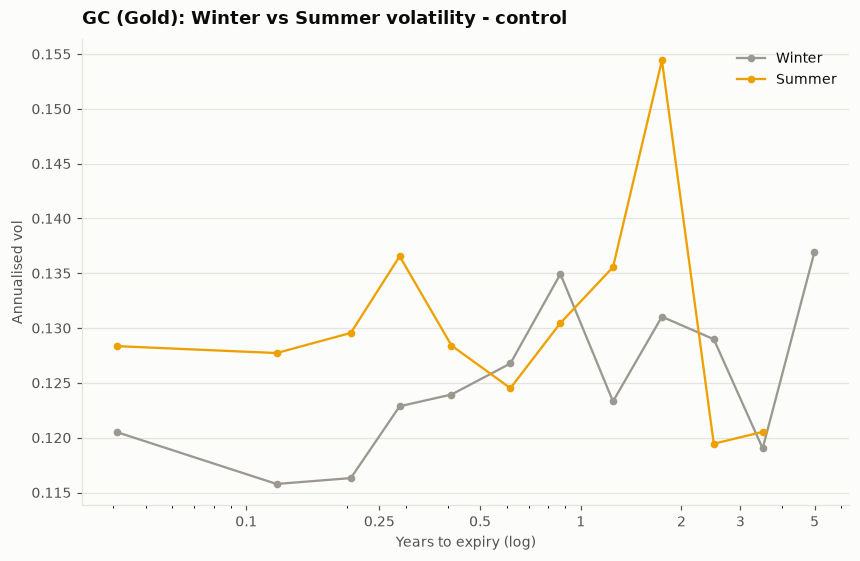

In [27]:
import charts_24_c as cc

fig, ax = cc.fig_C4({"seasonality": phase5})
plt.show()

**What this shows:** the same winter-vs-summer test as C1, applied to gold instead of natural gas.

**Does it match intuition?** Yes — and the *lack* of a gap here is the point. Nobody needs gold delivered in January to heat their home, so gold has no real delivery season. The two lines sitting almost on top of each other is the expected "nothing here" result, and it's reassuring evidence that C1's winter/summer gap for gas reflects a real seasonal effect rather than an artefact of the method.

In [28]:
ng_winter = phase5["ng_seasonality"]["winter"][0]["vol"]
ng_summer = phase5["ng_seasonality"]["summer"][0]["vol"]
gc_winter = phase5["gc_control"]["winter"][0]["vol"]
gc_summer = phase5["gc_control"]["summer"][0]["vol"]
print(
    f"NG front-end vol: winter={ng_winter:.3f} summer={ng_summer:.3f} "
    f"ratio={ng_winter / ng_summer:.2f}"
)
print(
    f"GC front-end vol: winter={gc_winter:.3f} summer={gc_summer:.3f} "
    f"ratio={gc_winter / gc_summer:.2f}"
)

NG front-end vol: winter=0.487 summer=0.380 ratio=1.28
GC front-end vol: winter=0.121 summer=0.128 ratio=0.94


## Section D — the realised smile/skew exploration

**Every chart below is realised, not implied.** There are no options in this repo, so a true implied-vol smile is impossible -- these are realised analogues built from settlement prices, and are labelled that way everywhere. Five figures over Phase 6.

**D1.** Realised skewness by maturity bucket, all 16 products, sector-coloured.

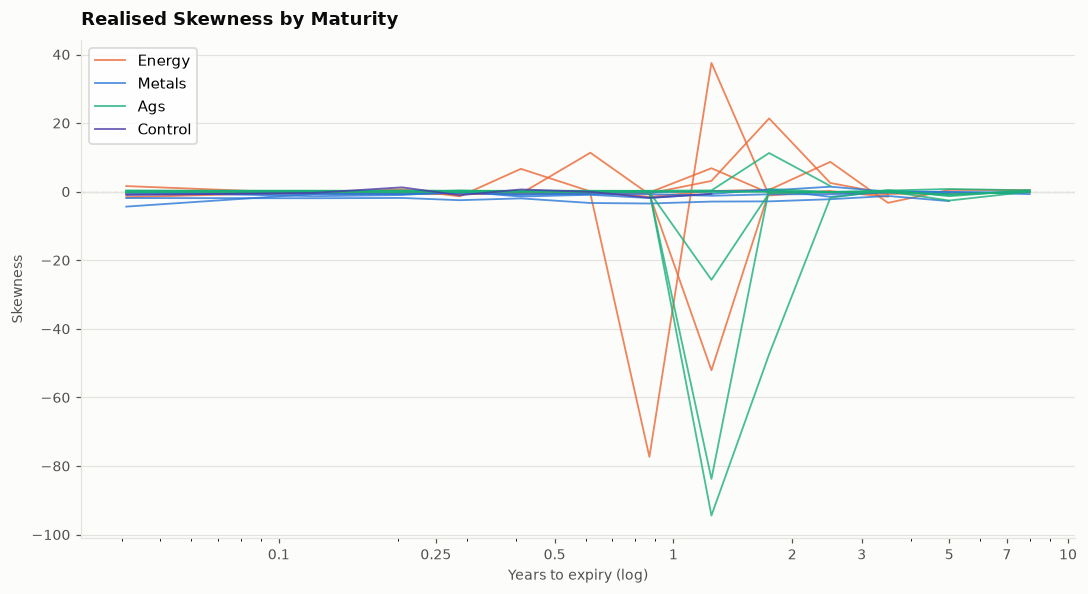

In [29]:
import charts_24_d as cd

fig, ax = cd.fig_D1({"smile_skew": phase6})
plt.show()

**What this shows:** how lopsided each product's daily price moves are at each maturity — a negative number means big down-days are more extreme or more common than big up-days, and vice versa.

**Does it match intuition?** Partially — energy products (orange) tend toward negative skew at the front of the curve, consistent with how commodity crashes (like the 2020 oil collapse) tend to be sharper than commodity rallies. The pattern is noisier further from expiry, where there's simply less data to pin down a shape confidently.

**D2.** Realised excess kurtosis by maturity bucket, log-y.

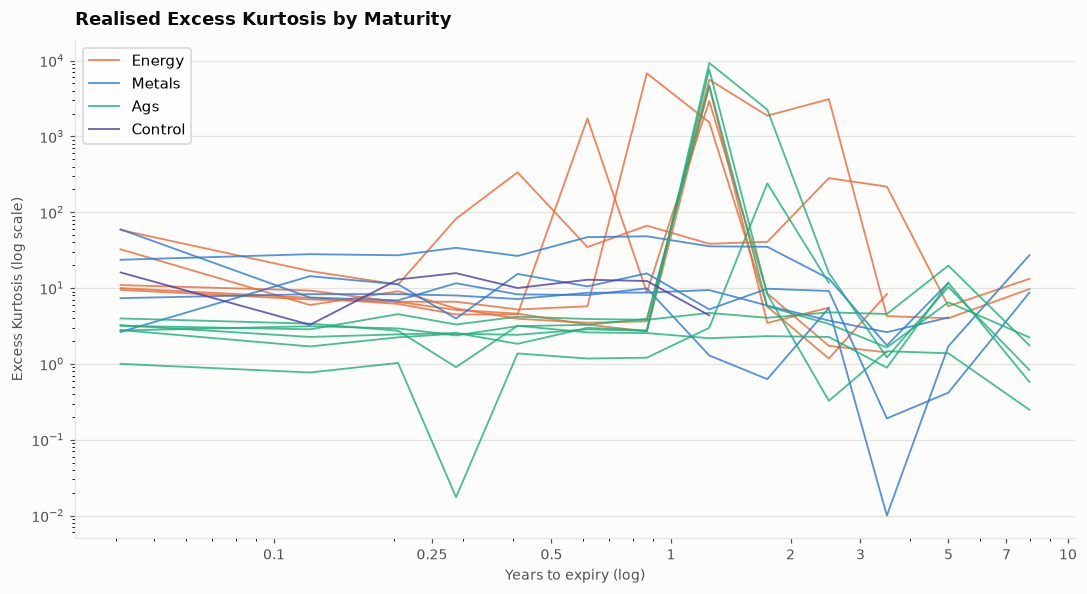

In [30]:
import charts_24_d as cd

fig, ax = cd.fig_D2({"smile_skew": phase6})
plt.show()

**What this shows:** how "fat-tailed" daily returns are at each maturity — how much more often extreme, surprising moves happen than a smooth bell-curve would predict. Higher means more shock-prone.

**Does it match intuition?** Yes — every product is fat-tailed to some degree (real markets always are), and the near-term end tends to be the most extreme, which lines up with the main finding: the front of the curve is where the biggest surprises land.

**D3.** The realised "smile": vol vs. log-moneyness, pooled and by maturity bin (the maturity/moneyness confound control).

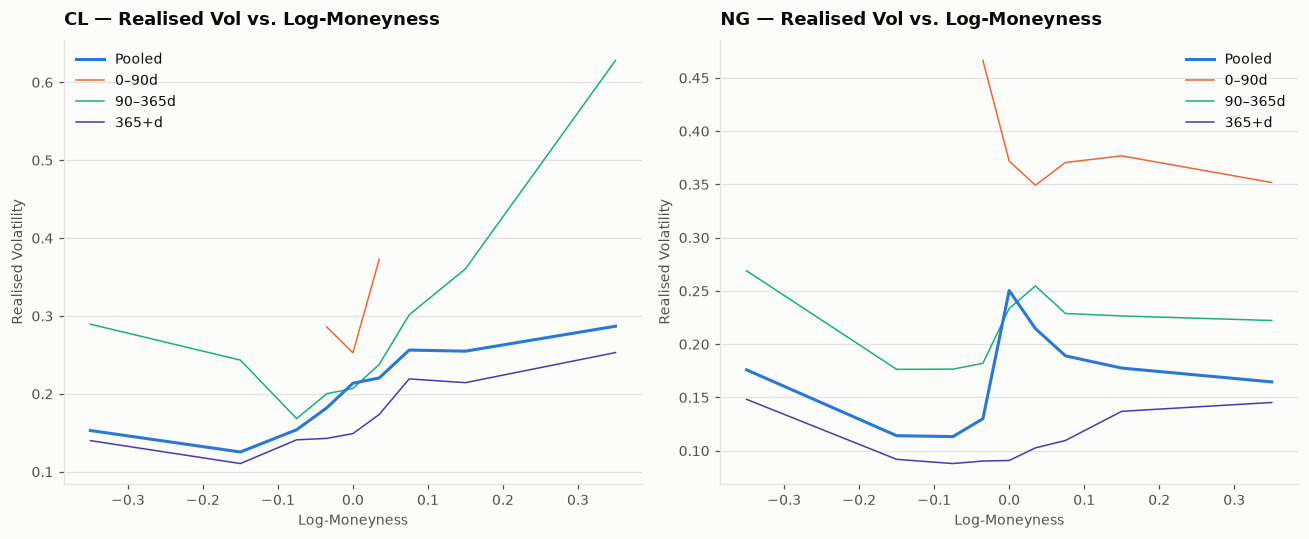

In [31]:
import charts_24_d as cd

fig, ax = cd.fig_D3({"smile_skew": phase6})
plt.show()

**What this shows:** the centrepiece of this section. Instead of plotting volatility against time-to-expiry, this plots it against how far a contract's price sits from the cheapest (front) contract that day. This is built from real settlement prices, not options, so it's labelled "realised," not "implied."

**Does it match intuition?** Partly. Crude oil is *not* a symmetric U — it dips slightly on the discounted (backwardated) side, then climbs steadily the further a contract trades at a premium (contango), so volatility is highest for contracts priced richest relative to the front, not symmetrically at both extremes. That shape survives even after controlling for time-to-expiry separately, so it's genuine, not the maturity effect in disguise. Natural gas looks different again — a real peaked hump centred near the front contract, falling off on both sides — which the write-up reports honestly rather than forcing it to match oil's shape.

**D4.** Vol-vs-dte split by curve state: contango vs. backwardation, CL and NG.

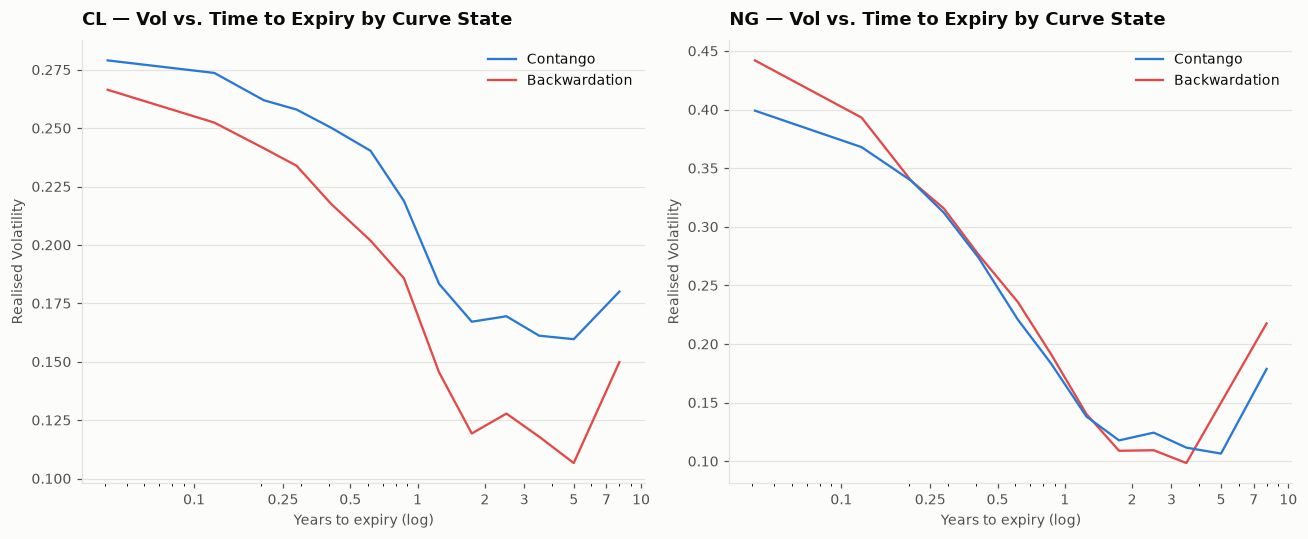

In [32]:
import charts_24_d as cd

fig, ax = cd.fig_D4({"smile_skew": phase6})
plt.show()

**What this shows:** the volatility-vs-time-to-expiry curve split depending on whether the market is currently short on supply (backwardation — near-term price higher) or oversupplied (contango).

**Does it match intuition?** For crude oil, yes — backwardated curves (scarcity) decline noticeably more steeply than contango curves, matching the idea that a shortage makes near-term news more urgent. For natural gas the two are essentially identical, so the effect isn't universal. (An earlier pass at this chart found the opposite for oil; that traced back to the same far-dated data-quality bug fixed elsewhere in this notebook — see the write-up's Bugs found section.)

**D5.** Front vs. deferred return densities, CL and NG, log-y.

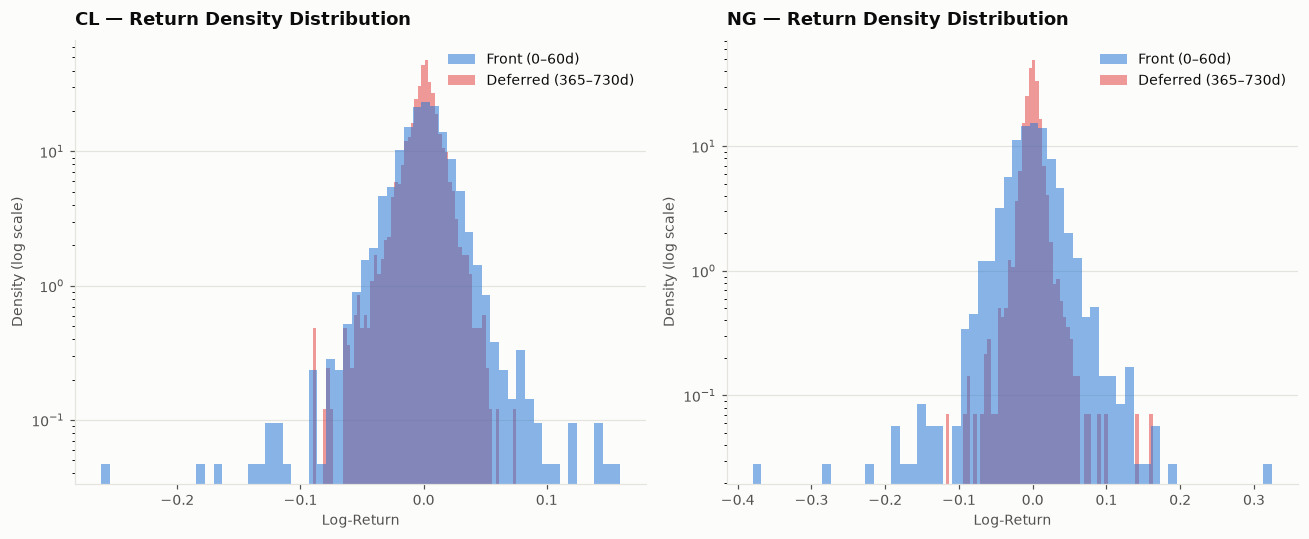

In [33]:
import charts_24_d as cd

fig, ax = cd.fig_D5({"smile_skew": phase6})
plt.show()

**What this shows:** the full shape of daily price moves for near-term vs. long-term contracts side by side, not just their average size — so you can see how often truly extreme days happen, not only how volatile things are on a typical day.

**Does it match intuition?** Yes — the near-term (blue) distribution is visibly wider and has fatter tails than the long-term (red) one, consistent with everything else in this notebook: the front of the curve doesn't just move more on average, it's also more prone to the rare, extreme day.

**Confound check:** CL's pooled realised smile is not a symmetric U -- it dips shallowly on the backwardated side then climbs steadily through contango -- but that asymmetric shape persists within each maturity bin, so it is not just the Samuelson effect in disguise. NG's pooled shape is genuinely different: a peaked hump centred near the front contract, also persisting once maturity is controlled for. The two products do not tell the same story, and neither is forced into matching the other.

**Curve-state check:** the naive expectation was that backwardated curves (signalling scarcity) would show a steeper Samuelson slope than contango curves. For CL, backwardation *is* markedly steeper (-0.218 vs. -0.149), matching that intuition. (An earlier pass at this check found the opposite sign for CL; that was traced to the far-dated data-quality bug documented in the write-up's Bugs found section and is superseded by the figure here.) For NG the two are nearly identical (-0.284 vs. -0.292).

## Bottom line

See `src/results/024_samuelson_effect_across_futures.md` for the full write-up.